# SQL-IDS: Tek Notebook Akisi (Detayli Aciklamali)

Bu notebook SQL Injection (SQLi) tespiti icin **tek dosyada**, **sinif (class) kullanmadan**, adim adim ilerleyen bir makine ogrenmesi akisi sunar.

Bu surumde:
- Markdown bolumleri daha detayli hale getirildi.
- Kod hucresindeki satirlarin ne yaptigini anlatan yorumlar guclendirildi.
- Cikti olarak modeller, confusion matrix grafikleri ve performans karsilastirma grafigi dosyaya kaydedilir.

## 1) Hazirlik ve Veri Temizligi

Bu bolumde tum kutuphaneler import edilir ve ham dataset modele uygun hale getirilir.
Amaç: modele girmeden once veriyi tutarli, temiz ve standard bir forma getirmek.

In [1]:
# Standart kutuphaneler
import os  # Dosya/klasor islemleri icin
import re  # Regex tabanli metin temizligi icin
import pickle  # Model ve vectorizer kaydetme/yukleme icin
from urllib.parse import unquote_plus  # URL decode islemi icin

# Veri ve gorsellestirme kutuphaneleri
import pandas as pd  # Tablo islemleri
import seaborn as sns  # Islenmis grafikler
import matplotlib.pyplot as plt  # Temel grafik cizimi

# Makine ogrenmesi kutuphaneleri
from sklearn.feature_extraction.text import TfidfVectorizer  # Metni sayisallastirma
from sklearn.model_selection import train_test_split  # Train/test ayirma
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix  # Degerlendirme metrikleri
from sklearn.ensemble import RandomForestClassifier, VotingClassifier  # RF + Ensemble modeli
from sklearn.svm import SVC  # SVM siniflandirici
from xgboost import XGBClassifier  # XGBoost siniflandirici

# Grafik temasini ve varsayilan boyutu belirle
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Veri yukleme ve temizlik

Bu adimda asagidaki islemler uygulanir:
- `dataset.csv` okunur.
- Gereksiz kolonlar (`Unnamed: 2`, `Unnamed: 3`) varsa kaldirilir.
- `Sentence` kolonu zorunlu olarak kontrol edilir.
- `Sentence` icinde bos/eksik (`NaN`) satirlar temizlenir.
- Tablodaki tum alanlar stringe cevrilir (tip tutarliligi icin).
- Label kolonu otomatik bulunur (`Label`, `label`, `Class`, vb.).

In [2]:
# Kullanilacak dataset dosya yolu
# Not: Asagidaki satiri ihtiyaca gore degistirebilirsin.
DATASET_PATH = "./data/merged_cleaned_preprocessed.csv"

# CSV dosyasini oku
# low_memory=False, buyuk dosyalarda tip tahmini kaynakli uyariyi azaltir.
df = pd.read_csv(DATASET_PATH, low_memory=False)

# Bazi kaynaklarda olusan gereksiz kolonlari (varsa) temizle
# errors='ignore' oldugu icin kolon yoksa hata vermez.
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3"], errors="ignore")

# Ana metin kolonu zorunlu kontrolu
if "Sentence" not in df.columns:
    raise ValueError("Dataset icinde 'Sentence' kolonu bulunamadi.")

# Sentence kolonunda eksik veri (NaN) varsa temizle
df = df.dropna(subset=["Sentence"]).copy()

# Veri tiplerini stringe cevirerek tutarli isleme zemini hazirla
df = df.astype(str)

# Label kolonu farkli isimlerle gelebilecegi icin otomatik bul
possible_label_cols = ["Label", "label", "Class", "class", "Target", "target"]
label_col = next((col for col in possible_label_cols if col in df.columns), None)

# Label kolonu bulunmazsa anlamli hata ver
if label_col is None:
    raise ValueError("Label kolonu bulunamadi. Beklenen kolonlardan biri olmali.")

# Kontrol amacli boyut ve secilen label bilgisini yazdir
print("Veri boyutu:", df.shape)
print("Kullanilan label kolonu:", label_col)

# Ilk satirlari inceleme amacli goster
df.head()

Veri boyutu: (2322915, 2)
Kullanilan label kolonu: Label


,Sentence,Label
0,"update regions set keywords = ""airports in kou...",0
1,"update airport set home_link = ""http://www.kil...",0
2,"delete from airport_frequencies where type = ""...",1
3,"insert into airport (ident, type, name, latitu...",0
4,"select r.name as region_name, count(a.id) as a...",0


## 2) On Isleme ve Vektorlestirme

Bu bolumde modelleme oncesi metinler sayisal forma cevrilir:
- URL decode + lowercase + bosluk normalizasyonu uygulanir.
- Label degerleri binary (0/1) forma donusturulur.
- Veri `%80 train / %20 test` olarak ayrilir.
- `TfidfVectorizer` sadece train veride fit edilir (data leakage olmamasi icin).
- Test veri ayni vectorizer ile sadece transform edilir.

In [3]:
# Metin on-isleme fonksiyonu
# Her satirda URL decode + lowercase + bosluk normallestirme yapar.
def clean_text(text):
    """URL decode + lowercase + whitespace normalization."""
    text = unquote_plus(str(text))  # URL kodlu karakterleri ac (ornek: %27 -> ')
    text = text.lower().strip()  # Kucuk harfe cevir ve basa/sona bosluk temizle
    text = re.sub(r"\s+", " ", text)  # Coklu bosluklari tek bosluga indir
    return text


# Sentence kolonuna temizleme fonksiyonunu uygula
df["clean_text"] = df["Sentence"].apply(clean_text)

# Etiketleri binary forma cevir (0: benign, 1: malicious)
malicious_labels = {"1", "true", "yes", "sqli", "malicious", "attack"}

# Label kolonunu normalize et ve set icindeyse 1 degilse 0 ata
df["y"] = df[label_col].str.strip().str.lower().apply(
    lambda x: 1 if x in malicious_labels else 0
)

# Oncesi-sonrasi kontrol icin ilk satirlari goster
print(df[["Sentence", "clean_text", "y"]].head())

                                            Sentence  \
0  update regions set keywords = "airports in kou...   
1  update airport set home_link = "http://www.kil...   
2  delete from airport_frequencies where type = "...   
3  insert into airport (ident, type, name, latitu...   
4  select r.name as region_name, count(a.id) as a...   

                                          clean_text  y  
0  update regions set keywords = "airports in kou...  0  
1  update airport set home_link = "http://www.kil...  0  
2  delete from airport_frequencies where type = "...  1  
3  insert into airport (ident, type, name, latitu...  0  
4  select r.name as region_name, count(a.id) as a...  0  


### Train-test split ve TF-IDF

Bu alt adimda once train/test ayrimi yapilir, sonra TF-IDF kurulup train veride ogrenilir.
Bu sira onemlidir: once tum veride fit etmek test bilgisinin modele sizmasina yol acar.

In [4]:
# Model girdisi (temiz metin) ve hedef etiket
X_text = df["clean_text"]
y = df["y"]

# Veriyi train/test olarak ayir
# stratify=y: sinif dagilimini train ve testte benzer tutar.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# TF-IDF nesnesini olustur
# max_features=5000: en bilgilendirici ilk 5000 ozellik
# ngram_range=(1,2): unigram + bigram kullan
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Sadece train veride fit + transform yap (data leakage'i onler)
X_train = tfidf_vectorizer.fit_transform(X_train_text)

# Test veriyi ayni vectorizer ile sadece transform et
X_test = tfidf_vectorizer.transform(X_test_text)

# Boyut kontrolu
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (1858332, 5000)
X_test shape : (464583, 5000)


## 3) Bireysel Model Egitimi ve Kayit

Bu bolumde her model bagimsiz olarak egitilir:
- XGBoost
- Random Forest
- SVM/Linear-SVM benzeri model
- Logistic Regression (notebookta kullanilan yapiya gore)

Ardindan modeller ve vectorizer dosyaya (`.pkl`) kaydedilir.

In [5]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from xgboost import XGBClassifier

# XGBoost modeli
# n_estimators: agac sayisi
# max_depth: agac derinligi
# learning_rate: ogrenme hizi
# tree_method='hist': hizli histogram tabanli egitim
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

# Random Forest modeli
# max_depth siniri overfit riskini azaltmaya yardimci olur.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
)

# SGD tabanli lineer model (SVM alternatifi)
# loss='log_loss' olasilik tabanli ensemble yapisina daha uyumludur.
sgd_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    tol=1e-3,
    n_jobs=-1,
    random_state=42,
)

# Logistic Regression modeli (guclu baseline)
lr_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    random_state=42,
)

# Tum modelleri tek bir sozlukte topluyoruz
models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "SGD (Linear SVM)": sgd_model,
    "Logistic Regression": lr_model,
}

# Her modeli tek tek egitiyoruz
for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{model_name} modeli egitildi.")


XGBoost modeli egitildi.
Random Forest modeli egitildi.
SGD (Linear SVM) modeli egitildi.


c:\Users\Mrt\Documents\Murat\project002\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression modeli egitildi.


### Modellerin ve TF-IDF nesnesinin kaydedilmesi

Bu adim yeniden egitim yapmadan modeli tekrar kullanabilmek icin gereklidir.
Model ve vectorizer artefaktlari `models/` klasorune yazilir.

In [6]:
import os
import pickle

# Model artefaktlarini yazmak icin klasor olustur (yoksa)
os.makedirs("models", exist_ok=True)

# XGBoost modelini kaydet
with open("./models/xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Random Forest modelini kaydet
with open("./models/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# SGD modelini kaydet
with open("./models/sgd_model.pkl", "wb") as f:
    pickle.dump(sgd_model, f)

# Logistic Regression modelini kaydet
with open("./models/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# TF-IDF vectorizer nesnesini kaydet
with open("./models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("Tum modeller ve vectorizer basariyla kaydedildi.")

Tum modeller ve vectorizer basariyla kaydedildi.


## 4) Performans Degerlendirmesi

Bu bolumde her model test veri uzerinde degerlendirilir.
- `classification_report` ile precision/recall/f1 detaylari yazdirilir.
- Confusion matrix hem gosterilir hem de dosyaya (`plots/`) kaydedilir.
- Model bazli Accuracy ve F1-Skoru toplanip karsilastirma icin saklanir.

In [7]:
import pickle

# Daha once kaydedilen model dosyalarini tekrar yukle
# Bu adim yeniden egitim yapmadan degerlendirme icin kullanilir.
with open("./models/xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open("./models/random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("./models/sgd_model.pkl", "rb") as f:
    sgd_model = pickle.load(f)

with open("./models/logistic_regression_model.pkl", "rb") as f:
    lr_model = pickle.load(f)

# TF-IDF vectorizer nesnesini yukle
with open("./models/tfidf_vectorizer.pkl", "rb") as f:
    tfidf_vectorizer = pickle.load(f)

print("Tum modeller ve vectorizer basariyla yuklendi.")

# Gerekirse manuel test icin ornek kod:
# raw_texts = ["ornek metin 1", "ornek metin 2"]
# X_test_transformed = tfidf_vectorizer.transform(raw_texts)
# y_pred = ensemble_model.predict(X_test_transformed)
# print(y_pred)

Tum modeller ve vectorizer basariyla yuklendi.



===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    400238
           1       1.00      0.98      0.99     64345

    accuracy                           1.00    464583
   macro avg       1.00      0.99      0.99    464583
weighted avg       1.00      1.00      1.00    464583



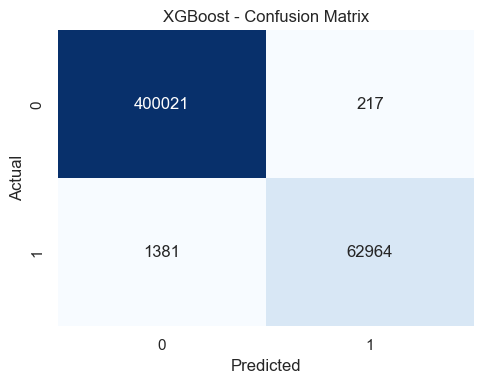


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    400238
           1       1.00      0.82      0.90     64345

    accuracy                           0.98    464583
   macro avg       0.99      0.91      0.94    464583
weighted avg       0.98      0.98      0.97    464583



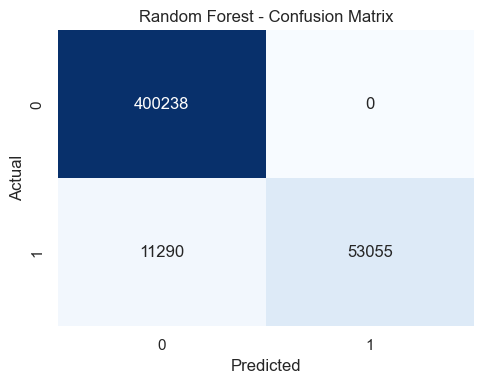


===== SGD (Linear SVM) =====
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    400238
           1       0.99      0.81      0.89     64345

    accuracy                           0.97    464583
   macro avg       0.98      0.90      0.94    464583
weighted avg       0.97      0.97      0.97    464583



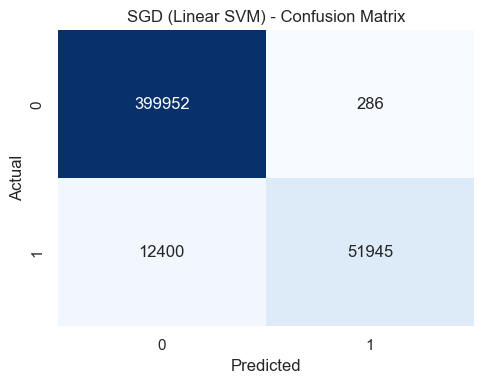


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    400238
           1       1.00      0.97      0.98     64345

    accuracy                           1.00    464583
   macro avg       1.00      0.99      0.99    464583
weighted avg       1.00      1.00      1.00    464583



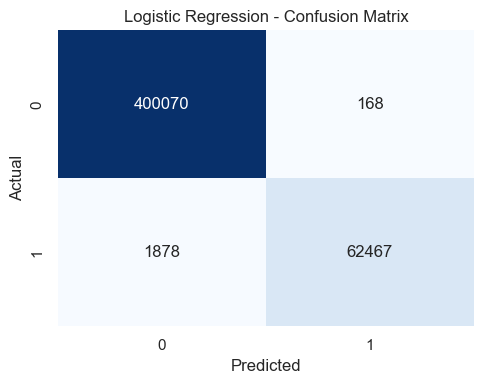


Tum modellerin karsilastirmali metrikleri:

                 Model  Accuracy  F1-Score
0              XGBoost  0.996560  0.987469
1        Random Forest  0.975699  0.903833
2     SGD (Linear SVM)  0.972694  0.891178
3  Logistic Regression  0.995596  0.983887


In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Plot dosyalari icin klasor
os.makedirs("plots", exist_ok=True)

metrics_rows = []

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")

    # Tahmin
    y_pred = model.predict(X_test)

    # Metrikler
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    metrics_rows.append({"Model": model_name, "Accuracy": acc, "F1-Score": f1})

    # Classification Report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    # Dosyaya kaydet (or: xgboost_confusion_matrix.png)
    file_key = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f"./plots/{file_key}_confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

# Opsiyonel: metrics dataframe
import pandas as pd
metrics_df = pd.DataFrame(metrics_rows)
print("\nTum modellerin karsilastirmali metrikleri:\n")
print(metrics_df)

## 5) Ensemble (Topluluk) Mimarisi

Bu bolumde temel modeller tek bir topluluk modelinde birlestirilir.
`VotingClassifier` (soft voting) ile model olasiliklari bir araya getirilir.
Ensemble sonucu da confusion matrix olarak kaydedilir ve model `.pkl` olarak disariya yazilir.


===== Ensemble =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    400238
           1       1.00      0.96      0.98     64345

    accuracy                           0.99    464583
   macro avg       1.00      0.98      0.99    464583
weighted avg       0.99      0.99      0.99    464583



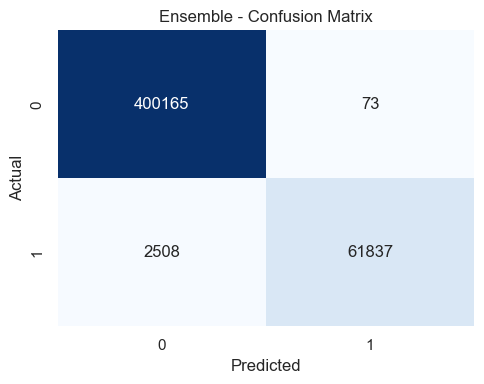

ensemble_model.pkl basariyla kaydedildi.
./plots/ensemble_confusion_matrix.png basariyla kaydedildi.


In [9]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# Klasorleri garanti et
os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# Ensemble modeli (mevcut modellerle)
ensemble_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model),
        ("sgd", sgd_model),
        ("lr", lr_model),
    ],
    voting="soft",
    n_jobs=-1,
)

# Fit
ensemble_model.fit(X_train, y_train)

# Tahmin
y_pred_ensemble = ensemble_model.predict(X_test)

# Metrikler
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
ensemble_f1 = f1_score(y_test, y_pred_ensemble, zero_division=0)
metrics_rows.append({
    "Model": "Ensemble",
    "Accuracy": ensemble_acc,
    "F1-Score": ensemble_f1,
})

print("\n===== Ensemble =====")
print(classification_report(y_test, y_pred_ensemble, zero_division=0))

# Confusion Matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ensemble, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("./plots/ensemble_confusion_matrix.png", dpi=150)
plt.show()
plt.close()

# Modeli kaydet
with open("models/ensemble_model.pkl", "wb") as file:
    pickle.dump(ensemble_model, file)

print("ensemble_model.pkl basariyla kaydedildi.")
print("./plots/ensemble_confusion_matrix.png basariyla kaydedildi.")

## 6) Gorsellestirme

Bu bolumde tum modellerin performansi tek grafikte karsilastirilir.
- Metric: Accuracy ve F1-Score
- Cikti: `plots/model_performance_comparison.png`

Boylece hangi modelin dengeli performans verdigi hizlica gorulebilir.

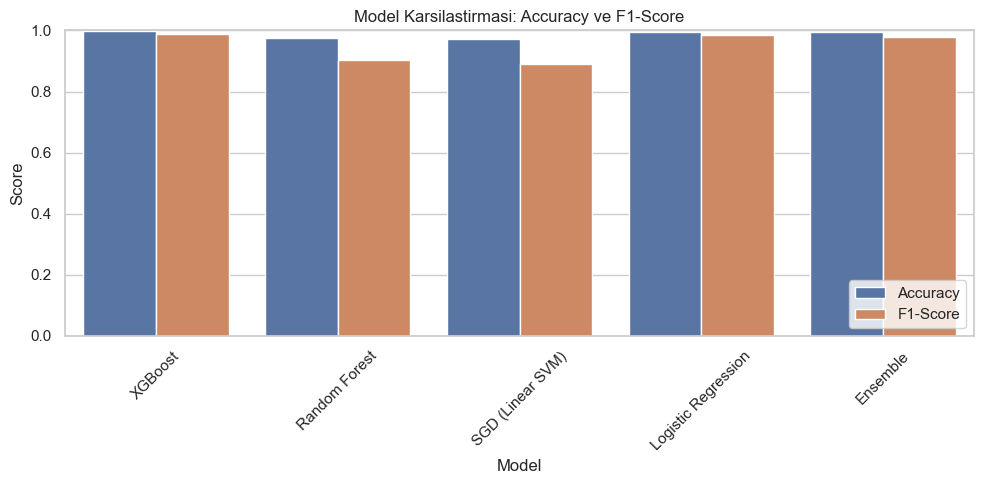

./plots/model_performance_comparison.png basariyla kaydedildi.


,Model,Accuracy,F1-Score
0,XGBoost,0.996560,0.987469
1,Random Forest,0.975699,0.903833
2,SGD (Linear SVM),0.972694,0.891178
3,Logistic Regression,0.995596,0.983887
4,Ensemble,0.994444,0.979557


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot klasoru garanti
os.makedirs("plots", exist_ok=True)

# metrics_rows onceki adimlardan geliyor
metrics_df = pd.DataFrame(metrics_rows)

# Dataframe'i uzun formata cevir
metrics_melted = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

# Barplot
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Model Karsilastirmasi: Accuracy ve F1-Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("./plots/model_performance_comparison.png", dpi=150)
plt.show()
plt.close()

print("./plots/model_performance_comparison.png basariyla kaydedildi.")

# metrics dataframe'i goster
metrics_df